In [1]:
import geopandas as gpd
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
from itertools import combinations
from shapely.geometry import Point, Polygon, box
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Set the option to display all columns
pd.options.display.max_columns = None

# 1. Import and process data

- What types of data are we considering (pt, pl, pg)?
- Do the facilities in Fort Myers connect to facilities in nearby cities? If so, we may need to expand the scope of the analysis.

## fort myers

<Axes: >

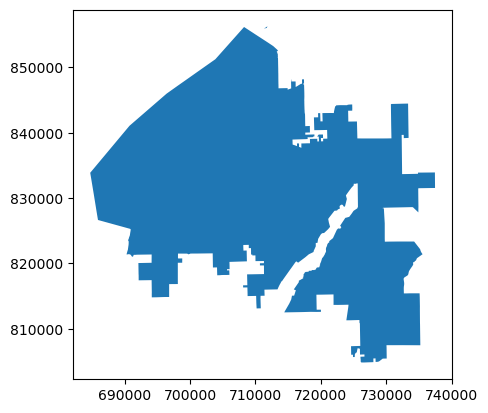

In [2]:
# Fort Myers city boundary
fort_myers_dir = r"../Data/Fort_Myers_City_Boundary/City_Boundary.shp"
fort_myers_boundary = gpd.read_file(fort_myers_dir)
fort_myers_boundary.plot()

In [3]:
fort_myers_boundary.crs

<Projected CRS: PROJCS["NAD83 / Florida West (ftUS)",GEOGCS["NAD83 ...>
Name: NAD83 / Florida West (ftUS)
Axis Info [cartesian]:
- [east]: Easting (US survey foot)
- [north]: Northing (US survey foot)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

## com, ele, and water

<Axes: >

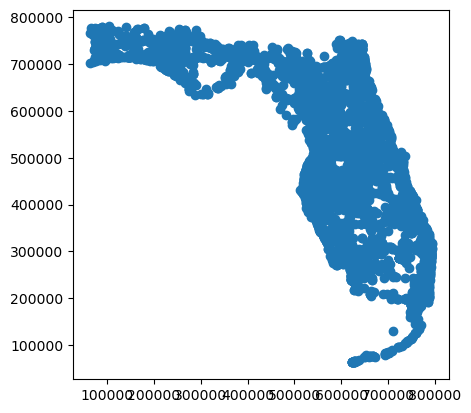

In [4]:
# test four kinds of CI
# Communication
communication_dir = r"../Data/Critical_Infrastructure/01_Communications_Facilities/Communications_Facilities.shp"
com = gpd.read_file(communication_dir)
com.plot()

<Axes: >

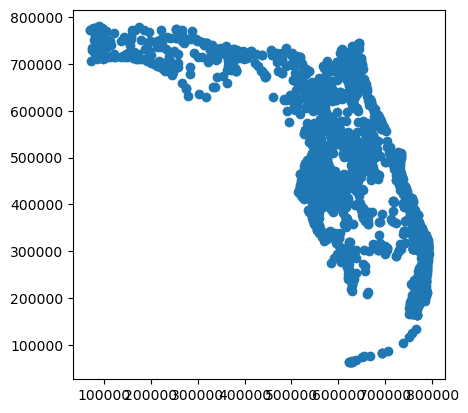

In [5]:
# Electric production and supply facilities
ele_dir = r"../Data/Critical_Infrastructure/04_Electric_Production_and_Supply_Facilities_-_PT/Electric_Production_and_Supply_Facilities_-_PT.shp"
ele = gpd.read_file(ele_dir)
ele.plot()

In [6]:
ele.head()

,SEQPLT,YEAR,PSTATABB,PNAME,ORISPL,OPRNAME,OPRCODE,UTLSRVNM,UTLSRVID,SECTOR,BANAME,BACODE,NERC,SUBRGN,SRNAME,ISORTO,FIPSST,FIPSCNTY,CNTYNAME,LAT,LON,CAMDFLAG,NUMUNT,NUMGEN,PLPRMFL,PLFUELCT,COALFLAG,CAPFAC,NAMEPCAP,NBFACTOR,RMBMFLAG,CHPFLAG,USETHRMO,PWRTOHT,ELCALLOC,PSFLAG,PLHTIAN,PLHTIOZ,PLHTIANT,PLHTIOZT,PLNGENAN,PLNGENOZ,PLNOXAN,PLNOXOZ,PLSO2AN,PLCO2AN,PLCH4AN,PLN2OAN,PLCO2EQA,PLHGAN,PLNOXRTA,PLNOXRTO,PLSO2RTA,PLCO2RTA,PLCH4RTA,PLN2ORTA,PLC2ERTA,PLHGRTA,PLNOXRA,PLNOXRO,PLSO2RA,PLCO2RA,PLCH4RA,PLN2ORA,PLC2ERA,PLHGRA,PLNOXCRT,PLNOXCRO,PLSO2CRT,PLCO2CRT,PLCH4CRT,PLN2OCRT,PLC2ECRT,PLHGCRT,UNNOX,UNNOXOZ,UNSO2,UNCO2,UNCH4,UNN2O,UNHG,UNHTI,UNHTIOZ,UNHTIT,UNHTIOZT,UNNOXSRC,UNNOZSRC,UNSO2SRC,UNCO2SRC,UNCH4SRC,UNN2OSRC,UNHGSRC,UNHTISRC,UNHOZSRC,BIONOX,BIONOXOZ,BIOSO2,BIOCO2,BIOCH4,BION2O,CHPCHTI,CHPCHTIOZ,CHPNOX,CHPNOXOZ,CHPSO2,CHPCO2,CHPCH4,CHPN2O,PLHTRT,PLGENACL,PLGENAOL,PLGENAGS,PLGENANC,PLGENAHY,PLGENABM,PLGENAWI,PLGENASO,PLGENAGT,PLGENAOF,PLGENAOP,PLGENATN,PLGENATR,PLGENATH,PLGENACY,PLGENACN,PLCLPR,PLOLPR,PLGSPR,PLNCPR,PLHYPR,PLBMPR,PLWIPR,PLSOPR,PLGTPR,PLOFPR,PLOPPR,PLTNPR,PLTRPR,PLTHPR,PLCYPR,PLCNPR,Name,Asset_Elev,Owned_Main,Asset,Asset_Sub_,Asset_Type,Asset_Grou,Asset_Rele,Asset_ID,Municipali,County,Water_Mana,Souce_Data,Souce_Da_1,Source_Ass,Restricted,Notes,OBJECTID_1,ID,CITY,STATE,ZIP,TYPE,STATUS,COUNTYFIPS,COUNTRY,LATITUDE,LONGITUDE,NAICS_CODE,NAICS_DESC,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,LINES,MAX_VOLT,MIN_VOLT,MAX_INFER,MIN_INFER,Regional_P,FDEP_Regul,RCP_Region,FDOT_Distr,House_Dist,Senate_Dis,CTF_RL_202,CTF_RL_204,CTF_RL_205,CTF_RL_207,CTF_RL_208,SSF_RL_100,SSF_RL_101,SSF_RL_102,SSF_RL_103,SSF_RL_104,SSF_RL_500,SSF_RL_501,SSF_RL_502,SSF_RL_503,SSF_RL_504,RIF_RL_100,RIF_RL_101,RIF_RL_102,RIF_RL_500,RIF_RL_501,RIF_RL_502,geometry
0,2485.0,2021.0,FL,ACE-Stanton A PV,61247.0,Orlando Utilities Comm,14610.0,"ACE-Stanton A, LLC",60863.0,IPP Non-CHP,Florida Municipal Power Pool,FMPP,SERC,FRCC,FRCC All,None,12,095,Orange,28.484550,-81.174110,None,1.0,1.0,SUN,SOLAR,None,0.24351,4.1,0.000000,None,None,0.0,0.0,0.0,None,0.000000e+00,0.00,7.734000e+04,34682.00,8746.0,3922.0,0.000,0.00,0.00,0.000,0.000,0.000,0.000,None,0.000,0.000,0.000,0.000,0.000,0.000,0.000,None,0.000,0.000,0.000,0.000,0.000,0.0,0.00,None,0.000,0.000,0.000,0.000,0.000,0.000,0.000,None,0.000,0.00,0.00,0.000,0.000,0.000,None,0.000000e+00,0.00,7.734000e+04,34682.00,None,None,None,None,None,None,--,EIA,EIA,None,None,None,None,None,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8746.0,0.0,0.0,0.0,0.0,8746.0,8746.0,0.0,8746.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,ACE-Stanton A PV,0.0,Orlando Utilities Comm,FloridaPowerPlantsFrom_eGRID_EPA_XY,None,Electric Production and Supply Facilities,Critical Infrastructure,Regionally Significant,ELC_PT_000001,None,Orange,St. Johns River Water Management District,EPA,FloridaPowerPlantsFrom_eGRID_EPA_XY,None,None,None,0,None,None,None,None,None,None,None,None,0.0,0.0,None,None,None,1899-12-30,None,1899-12-30,0.0,0.0,0.0,None,None,East Central Florida,Central District,Northeast,5,35,17,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,POINT (676111.903 500771.943)
1,2486.0,2021.0,FL,ACE-Stanton PV,61246.0,Orlando Utilities Comm,14610.0,"ACE-Stanton, LLC",60862.0,IPP Non-CHP,Florida Municipal Power Pool,FMPP,SERC,FRCC,FRCC All,None,12,095,Orange,28.477350,-81.180360,None,1.0,1.0,SUN,SOLAR,None,0.24584,4.8,0.000000,None,None,0.0,0.0,0.0,None,0.000000e+00,0.00,9.140800e+04,40991.00,10337.0,4636.0,0.000,0.00,0.00,0.000,0.000,0.000,0.000,None,0.000,0.000,0.000,0.000,0.000,0.000,0.000,None,0.000,0.000,0.000,0.000,0.000,0.0,0.00,None,0.000,0.000,0.000,0.000,0.000,0.000,0.000,None,0.000,0.00,0.00,0.000,0.000,0.000,None,0.000000e+00,0.00,9.140800e+04,40991.00,None,None

In [7]:
water_csv = pd.read_csv(r"../Data/Critical_Infrastructure/03_Drinking_Water_Facilities/Drinking_Water_Facilities.csv")
water_csv.head(2)

/var/folders/g3/6qgb9yms7_nfyz1zwmncn97m0000gn/T/ipykernel_53584/1908239707.py:1: DtypeWarning: Columns (58,60,61,62,67,69) have mixed types. Specify dtype option on import or set low_memory=False.
  water_csv = pd.read_csv(r"../Data/Critical_Infrastructure/03_Drinking_Water_Facilities/Drinking_Water_Facilities.csv")


,OBJECTID_1,GIS_WELL_I,PWS_ID,PWS_STATUS,WELL_STATU,PWS_NAME,PWS_ADDRES,PWS_CITY,PWS_ZIP5,PWS_PRIMAR,PWS_TYPE_C,PWS_TYPE,PWS_SUBPAR,PWS_OPERAT,PWS_POP_SE,WELL_LAT_D,WELL_LAT_M,WELL_LONG_,WELL_LON_1,WELL_METHO,WELL_DATUM,WELL_COORD,FLUWID,WELL_PLANT,WELL_ID,WELL_NAME,WELL_YEAR_,WELL_DEPTH,PWS_LAST_S,PWS_DESIGN,PWS_PRIM_1,WELL_AVAIL,WELL_HEIGH,PWS_INSPEC,PWS_CNP_CO,PWS_OC1_OF,LOCATIONS_,WELL_UNDER,OBJECTID,AQUIFER,Name,Asset Elevation,Owned / Maintained,Asset,Asset Sub-Type,Asset Type,Asset Group,Asset Relevancy,Asset ID,Municipality,County,Water Management District,Souce Dataset Entity,Souce Dataset Name,Source Asset ID,Restricted Public Disclosure,Notes,GIS_PLANT_,PWS_LAST_0,PLANT_ID,PLANT_NAME,PLANT_STAT,PLANT_FOUR,PLANT_LAT_,PLANT_LA_1,PLANT_LONG,PLANT_LO_1,PLANT_COOR,PLANT_DATU,PLANT_CO_1,PLANT_DESI,PLANT_HEIG,Regional_Planning_Council,FDEP Regulatory District,RCP Region,FDOT District,Fla House District Number,Fla Senate District Number,Coastal Tidal Flood Risk - 2020,Coastal Tidal Flood Risk - 2040 Intermediate-Low,Coastal Tidal Flood Risk - 2040 Intermediate,Coastal Tidal Flood Risk - 2070 Intermediate-Low,Coastal Tidal Flood Risk - 2070 Intermediate,Storm Surge Flood Risk - 100-Year Current,Storm Surge Flood Risk - 100-Year 2040 Intermediate-Low,Storm Surge Flood Risk - 100-Year 2040 Intermediate,Storm Surge Flood Risk - 100-Year 2070 Intermediate-Low,Storm Surge Flood Risk - 100-Year 2070 Intermediate,Storm Surge Flood Risk - 500-Year Current,Storm Surge Flood Risk - 500-Year 2040 Intermediate-Low,Storm Surge Flood Risk - 500-Year 2040 Intermediate,Storm Surge Flood Risk - 500-Year 2070 Intermediate-Low,Storm Surge Flood Risk - 500-Year 2070 Intermediate,Rainfall-Induced Flood Risk - 100-Year 2020,Rainfall-Induced Flood Risk - 100-Year 2040,Rainfall-Induced Flood Risk - 100-Year 2070,Rainfall-Induced Flood Risk - 500-Year 2020,Rainfall-Induced Flood Risk - 500-Year 2040,Rainfall-Induced Flood Risk - 500-Year 2070,x,y
0,1,15.0,1030371,ACTIVE,ACTIVE,"WESTROCK CP, LLC - PANAMA CITY MILL",1 EVERITT AVENUE,PANAMA CITY,32401.0,-2147483648,P,NONTRANSIENT NONCOMMUNITY,N,GREG KIDWELL,65,30.0,8.0,85.0,37.0,DGPS,83.0,4/8/1997 12:00:00 AM,AAA9308,1.0,1.0,WELL 5,1950.0,490.0,1/23/2020 12:00:00 AM,1346400.0,INDUSTRIAL/AGRICULTURAL,PERMANENT,-25.567,LJ,3.0,NWD,34.0,N,15,Floridan Aquifer,"WESTROCK CP, LLC - PANAMA CITY MILL",NaN,GREG KIDWELL,Public_Water_System_PWS_Wells,NaN,Drinking Water Facilities,Critical Infrastructure,Regionally Significant,DWF_000001,NaN,Bay,Northwest Florida Water Management District,FDEP,Public_Water_System_PWS_Wells,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Emerald Coast,Northwest District,Northwest,3,6,2,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Low,Medium,Medium,High,High,High,High,Low,Low,Low,Low,Low,Low,243872.3955,682763.8349
1,2,17.0,1030371,ACTIVE,ACTIVE,"WESTROCK CP, LLC - PANAMA CITY MILL",1 EVERITT AVENUE,PANAMA CITY,32401.0,-2147483648,P,NONTRANSIENT NONCOMMUNITY,N,GREG KIDWELL,65,30.0,8.0,85.0,37.0,DGPS,83.0,4/8/1997 12:00:00 AM,AAA9309,1.0,3.0,WELL 6,0.0,490.0,1/23/2020 12:00:00 AM,1346400.0,INDUSTRIAL/AGRICULTURAL,PERMANENT,-26.591,LJ,3.0,NWD,65060.0,N,17,Floridan Aquifer,"WESTROCK CP, LLC - PANAMA CITY MILL",NaN,GREG KIDWELL,Public_Water_System_PWS_Wells,NaN,Drinking Water Facilities,Critical Infrastructure,Regionally Significant,DWF_000002,NaN,Bay,Northwest Florida Water Management District,FDEP,Public_Water_System_PWS_Wells,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Emerald Coast,Northwest District,Northwest,3,6,2,Low,Medium,Medium,Medium,High,High,High,High,High,High,High,High,High,High,High,Not Affected,Not Affected,Not Affected,Not Affected,High,High,243678.4448,682492.6923


<Axes: >

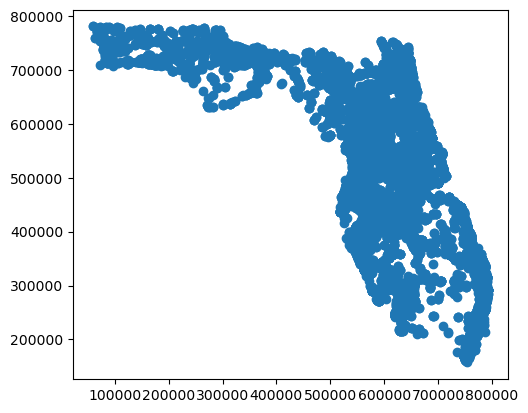

In [8]:
# Drinking water facilities
water = gpd.GeoDataFrame(
    water_csv,
    geometry=gpd.points_from_xy(water_csv['x'], water_csv['y']),
    crs=com.crs
)
water.plot()

In [9]:
water.to_file(r"../Data/Critical_Infrastructure/03_Drinking_Water_Facilities/Drinking_Water_Facilities.shp", driver='ESRI Shapefile', encoding='utf-8')

/var/folders/g3/6qgb9yms7_nfyz1zwmncn97m0000gn/T/ipykernel_4507/3070188004.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  water.to_file(r"../Data/Critical_Infrastructure/03_Drinking_Water_Facilities/Drinking_Water_Facilities.shp", driver='ESRI Shapefile', encoding='utf-8')
/opt/anaconda3/envs/demo/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Asset Elevation' to 'Asset Elev'
  ogr_write(
/opt/anaconda3/envs/demo/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Owned / Maintained' to 'Owned / Ma'
  ogr_write(
/opt/anaconda3/envs/demo/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Asset Sub-Type' to 'Asset Sub-'
  ogr_write(
/opt/anaconda3/envs/demo/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Asset Group' to 'Asset Grou'


In [9]:
com.crs

<Projected CRS: EPSG:3087>
Name: NAD83(HARN) / Florida GDL Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Florida.
- bounds: (-87.63, 24.41, -79.97, 31.01)
Coordinate Operation:
- name: Florida GDL Albers (meter)
- method: Albers Equal Area
Datum: NAD83 (High Accuracy Reference Network)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [10]:
ele.crs

<Projected CRS: EPSG:3087>
Name: NAD83(HARN) / Florida GDL Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Florida.
- bounds: (-87.63, 24.41, -79.97, 31.01)
Coordinate Operation:
- name: Florida GDL Albers (meter)
- method: Albers Equal Area
Datum: NAD83 (High Accuracy Reference Network)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [11]:
water.crs

<Projected CRS: EPSG:3087>
Name: NAD83(HARN) / Florida GDL Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Florida.
- bounds: (-87.63, 24.41, -79.97, 31.01)
Coordinate Operation:
- name: Florida GDL Albers (meter)
- method: Albers Equal Area
Datum: NAD83 (High Accuracy Reference Network)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

## road

In [ ]:
import osmnx as ox
place_name = "Florida, USA"

# Download the road network data
print(f"Downloading the driving network for '{place_name}' from OpenStreetMap...")
G = ox.graph_from_place(place_name, network_type='drive') # drive
print("Download complete!")

# Print some basic information
print(f"The network has {len(G.nodes)} nodes and {len(G.edges)} edges.")

# Visualize the network
print("Generating the network map...")

c:\Users\hai\anaconda3\envs\csml\lib\site-packages\osmnx\_overpass.py:254: UserWarning: This area is 142 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


In [4]:
fig, ax = ox.plot_graph(G, show=False, close=True)
plt.show()

In [ ]:
ox.save_graph_shapefile(G, filepath = r"../Data/osm/florida_drive_network.shp")

C:\Users\hai\AppData\Local\Temp\ipykernel_38716\1441734422.py:1: FutureWarning: The `save_graph_shapefile` function is deprecated and will be removed in the v2.0.0 release. Instead, use the `save_graph_geopackage` function to save graphs as GeoPackage files for subsequent GIS analysis. See the OSMnx v2 migration guide: https://github.com/gboeing/osmnx/issues/1123
  ox.save_graph_shapefile(G, filepath = r"../Data/osm/lee_drive_network.shp")
c:\Users\hai\anaconda3\envs\csml\lib\site-packages\osmnx\io.py:115: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf_nodes.to_file(filepath_nodes, driver="ESRI Shapefile", index=True, encoding=encoding)


In [ ]:
# nodes_only_gdf = ox.graph_to_gdfs(G, edges=False)


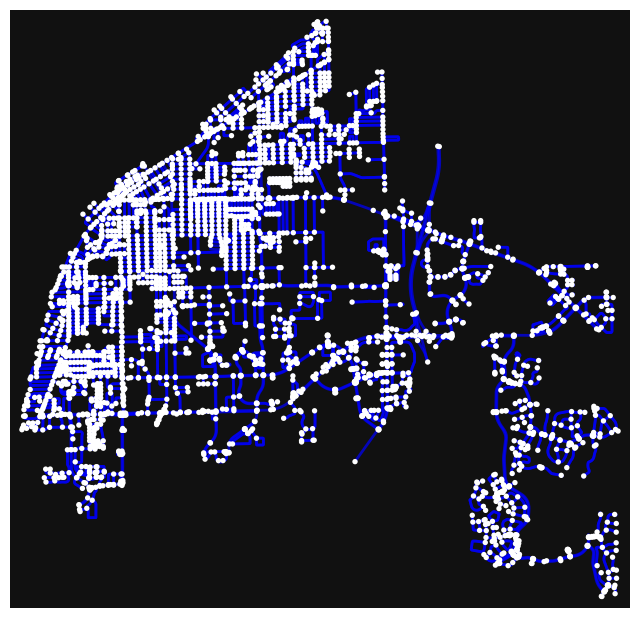

In [43]:
fig, ax = ox.plot_graph(G, 
                        edge_color='blue', 
                        edge_linewidth=2, 
                        edge_alpha=0.7,
                        show=True, 
                        close=True)

plt.show()

In [58]:
# The function returns nodes and edges, but we only need the edges
edges_gdf = ox.graph_to_gdfs(G, nodes=False)

# Inspect the first few rows of your new GeoDataFrame
print("GeoDataFrame of network edges created:")
print(edges_gdf.head())


GeoDataFrame of network edges created:
                          osmid      highway             name  oneway  \
u        v        key                                                   
98010989 98214828 0    11040386  residential  Seminole Avenue   False   
         98010993 0    11005899  residential     Duffy Street   False   
         98038443 0    11040386  residential  Seminole Avenue   False   
98010993 98010989 0    11005899  residential     Duffy Street   False   
         98257897 0    11039560  residential   Estelle Street   False   

                      reversed      length  \
u        v        key                        
98010989 98214828 0      False   34.011837   
         98010993 0      False  105.063902   
         98038443 0       True  210.534192   
98010993 98010989 0       True  105.063902   
         98257897 0      False   76.418141   

                                                                geometry  \
u        v        key                             

In [ ]:
# print(type(nodes_only_gdf))
# print(nodes_only_gdf.shape)

<class 'geopandas.geodataframe.GeoDataFrame'>
(3388, 6)


In [ ]:
# nodes_only_gdf.to_file(r"../Data/osm/drive_network_nodes.shp", driver='ESRI Shapefile', encoding='utf-8')

C:\Users\hai\AppData\Local\Temp\ipykernel_10308\3090300039.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes_only_gdf.to_file(r"../Data/osm/drive_network_nodes.shp", driver='ESRI Shapefile', encoding='utf-8')


<Axes: >

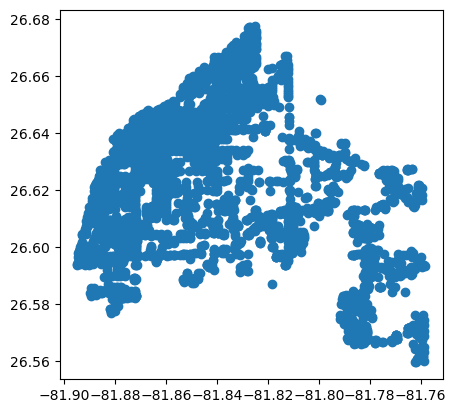

In [ ]:
road_dir = r"../Data/osm/drive_network_nodes.shp"
road = gpd.read_file(road_dir)
road.plot()

<Axes: >

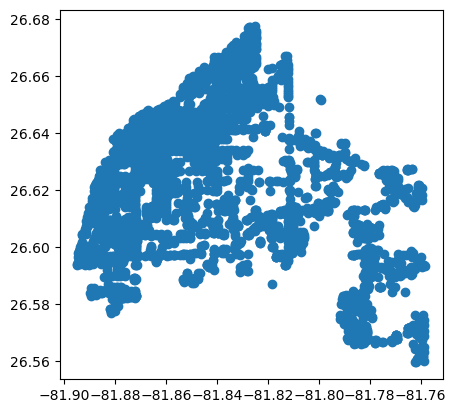

In [38]:
road_network_dir = r"../Data/osm/drive_network.shp"
road_network = gpd.read_file(road_dir)
road_network.plot()

In [13]:
road.head(2)

,osmid,y,x,street_cou,highway,ref,geometry
0,98010989,26.664304,-81.839102,3,None,None,POINT (-81.8391 26.6643)
1,98010993,26.663580,-81.838423,3,None,None,POINT (-81.83842 26.66358)


In [14]:
road.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## hospital

In [15]:
hospital_lat = 26.641581810614476
hospital_lon = -81.86429982742719

hospital_gdf = gpd.GeoDataFrame({
    'Facility': ['Hospital'],
    'geometry': [Point(hospital_lon, hospital_lat)],
})


In [18]:
# Define the target CRS from your data layers
target_crs = "EPSG:3087"

In [19]:
hospital_gdf = gpd.GeoDataFrame(hospital_gdf, geometry='geometry', crs="EPSG:4326")
hospital = hospital_gdf.to_crs(target_crs)


In [20]:
hospital.crs

<Projected CRS: EPSG:3087>
Name: NAD83(HARN) / Florida GDL Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Florida.
- bounds: (-87.63, 24.41, -79.97, 31.01)
Coordinate Operation:
- name: Florida GDL Albers (meter)
- method: Albers Equal Area
Datum: NAD83 (High Accuracy Reference Network)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

## clip using fort myers boundary

In [21]:
fort_myers_boundary = fort_myers_boundary.to_crs(target_crs)
fort_myers_boundary.crs

<Projected CRS: EPSG:3087>
Name: NAD83(HARN) / Florida GDL Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Florida.
- bounds: (-87.63, 24.41, -79.97, 31.01)
Coordinate Operation:
- name: Florida GDL Albers (meter)
- method: Albers Equal Area
Datum: NAD83 (High Accuracy Reference Network)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [22]:
road_nodes = road.to_crs(target_crs)
road_nodes.crs

<Projected CRS: EPSG:3087>
Name: NAD83(HARN) / Florida GDL Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Florida.
- bounds: (-87.63, 24.41, -79.97, 31.01)
Coordinate Operation:
- name: Florida GDL Albers (meter)
- method: Albers Equal Area
Datum: NAD83 (High Accuracy Reference Network)
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [23]:
# dissolve the boundary into one shape for a clean clip
fort_myers_boundary_un = fort_myers_boundary.unary_union
type(fort_myers_boundary_un)

/var/folders/g3/6qgb9yms7_nfyz1zwmncn97m0000gn/T/ipykernel_53584/2830961096.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fort_myers_boundary_un = fort_myers_boundary.unary_union


shapely.geometry.multipolygon.MultiPolygon

In [24]:
com_clipped_raw = gpd.clip(com, fort_myers_boundary)
print(f"-> Original 'com' features: {len(com)}, Clipped features: {len(com_clipped_raw)}")

ele_clipped_raw = gpd.clip(ele, fort_myers_boundary)
print(f"-> Original 'ele' features: {len(ele)}, Clipped features: {len(ele_clipped_raw)}")

water_clipped_raw = gpd.clip(water, fort_myers_boundary)
print(f"-> Original 'water' features: {len(water)}, Clipped features: {len(water_clipped_raw)}")

road_nodes_clipped_raw = gpd.clip(road_nodes, fort_myers_boundary)
print(f"-> Original 'road_nodes' features: {len(road_nodes)}, Clipped features: {len(road_nodes_clipped_raw)}")

-> Original 'com' features: 6697, Clipped features: 38
-> Original 'ele' features: 2211, Clipped features: 6
-> Original 'water' features: 15265, Clipped features: 18
-> Original 'road_nodes' features: 3388, Clipped features: 3362


## clean data

In [25]:
print(com_clipped_raw.shape)
print(ele_clipped_raw.shape)
print(water_clipped_raw.shape)
print(road_nodes_clipped_raw.shape)

(38, 78)
(6, 208)
(18, 102)
(3362, 7)


In [26]:
com_clipped_raw.head()

,OBJECTID_1,Permanent_,Source_Fea,Source_Dat,Source_D_1,Source_Ori,Data_Secur,Distributi,LoadDate,FType,FCode,Name,IsLandmark,PointLocat,AdminType,AddressBui,Address,City,State,Zipcode,GNIS_ID,Foot_ID,Complex_ID,OBJECTID__,Ftype_jn,Fcode_jn,Asset_Elev,Owned_Main,Asset,Asset_Sub_,Asset_Type,Asset_Grou,Asset_Rele,Asset_ID,Municipali,County,Water_Mana,Souce_Data,Souce_Da_1,Source_Ass,Restricted,Notes,Zip,X,Y,LONGLAT,USNG,OWNERSHIP,PARCELID,FACILITY_T,Regional_P,FDEP_Regul,RCP_Region,FDOT_Distr,House_Dist,Senate_Dis,CTF_RL_202,CTF_RL_204,CTF_RL_205,CTF_RL_207,CTF_RL_208,SSF_RL_100,SSF_RL_101,SSF_RL_102,SSF_RL_103,SSF_RL_104,SSF_RL_500,SSF_RL_501,SSF_RL_502,SSF_RL_503,SSF_RL_504,RIF_RL_100,RIF_RL_101,RIF_RL_102,RIF_RL_500,RIF_RL_501,RIF_RL_502,geometry
31,230,1202b28a-e95f-45e9-856f-564faad08aaf,None,{3CE051CA-9F5E-42E2-9EDC-FFA501EEBB25},FL Post Offices from Census Bureau processed w...,U.S. Census Bureau,5,E4,2018-02-02,780,78006,Page Field Post Office,2,1,1,None,2655 North Airport Road,Fort Myers,FL,33907,2449027,None,None,230.0,Mail and Shipping,Post Office,0.0,None,Post Offices - NSD,None,Communications Facilities,Critical Infrastructure,Locally Significant,COM_000032,Fort Myers,Lee,South Florida Water Management District,USGS NSD,Post Offices - NSD,None,None,None,None,0.0000,0.0000,None,None,None,None,None,Southwest Florida,South District,Southwest,1,78,33,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,POINT (612902.65 289558.297)
3513,2735,None,None,None,None,None,0,None,1899-12-30,0,0,STC FIVE LLC,0,0,0,None,4607 FOWLER ST,FORT MYERS,None,None,None,None,None,0.0,None,None,0.0,None,Communications - FDEM,None,Communications Facilities,Critical infrastructure,Locally Significant,COM_003514,Fort Myers,Lee,South Florida Water Management District,FDEM,Communications - FDEM,None,None,None,33907,-81.8627,26.5949,"-81.86270000,26.59490000",17R MK 14100 41857,None,014524P2000620030,RADIO COMMUNICATIONS TOWER,Southwest Florida,South District,Southwest,1,78,33,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Low,Low,POINT (612475.65 289618.184)
3629,2851,None,None,None,None,None,0,None,1899-12-30,0,0,STC FIVE LLC,0,0,0,None,4607 FOWLER ST,FORT MYERS,None,None,None,None,None,0.0,None,None,0.0,None,Communications - FDEM,None,Communications Facilities,Critical infrastructure,Locally Significant,COM_003514,Fort Myers,Lee,South Florida Water Management District,FDEM,Communications - FDEM,None,None,None,33907,-81.8627,26.5949,"-81.86270000,26.59490000",17R MK 14100 41857,None,014524P2000620030,RADIO COMMUNICATIONS TOWER,Southwest Florida,South District,Southwest,1,78,33,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Low,Low,POINT (612475.65 289618.184)
3567,2789,None,None,None,None,None,0,None,1899-12-30,0,0,QUALICOM SYSTEMS INC DBA = QUALICOM,0,0,0,None,4426 CLEVELAND AVE,FORT MYERS,None,None,None,None,None,0.0,None,None,0.0,None,Communications - FDEM,None,Communications Facilities,Critical infrastructure,Locally Significant,COM_003568,Fort Myers,Lee,South Florida Water Management District,FDEM,Communications - FDEM,None,None,None,33901,-81.8725,26.5981,"-81.87250000,26.59810000",17R MK 13127 42218,None,354424P3000730000,RADIO COMMUNICATIONS TOWER,Southwest Florida,South District,Southwest,1,78,33,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not

In [27]:
com_clipped_raw["Source_Ori"].unique()

array(['U.S. Census Bureau', None, 'U.S. Geological Survey'], dtype=object)

In [28]:
com_clipped = com_clipped_raw[com_clipped_raw['Source_Ori'].notna()]
com_clipped

,OBJECTID_1,Permanent_,Source_Fea,Source_Dat,Source_D_1,Source_Ori,Data_Secur,Distributi,LoadDate,FType,FCode,Name,IsLandmark,PointLocat,AdminType,AddressBui,Address,City,State,Zipcode,GNIS_ID,Foot_ID,Complex_ID,OBJECTID__,Ftype_jn,Fcode_jn,Asset_Elev,Owned_Main,Asset,Asset_Sub_,Asset_Type,Asset_Grou,Asset_Rele,Asset_ID,Municipali,County,Water_Mana,Souce_Data,Souce_Da_1,Source_Ass,Restricted,Notes,Zip,X,Y,LONGLAT,USNG,OWNERSHIP,PARCELID,FACILITY_T,Regional_P,FDEP_Regul,RCP_Region,FDOT_Distr,House_Dist,Senate_Dis,CTF_RL_202,CTF_RL_204,CTF_RL_205,CTF_RL_207,CTF_RL_208,SSF_RL_100,SSF_RL_101,SSF_RL_102,SSF_RL_103,SSF_RL_104,SSF_RL_500,SSF_RL_501,SSF_RL_502,SSF_RL_503,SSF_RL_504,RIF_RL_100,RIF_RL_101,RIF_RL_102,RIF_RL_500,RIF_RL_501,RIF_RL_502,geometry
31,230,1202b28a-e95f-45e9-856f-564faad08aaf,None,{3CE051CA-9F5E-42E2-9EDC-FFA501EEBB25},FL Post Offices from Census Bureau processed w...,U.S. Census Bureau,5,E4,2018-02-02,780,78006,Page Field Post Office,2,1,1,None,2655 North Airport Road,Fort Myers,FL,33907,2449027,None,None,230.0,Mail and Shipping,Post Office,0.0,None,Post Offices - NSD,None,Communications Facilities,Critical Infrastructure,Locally Significant,COM_000032,Fort Myers,Lee,South Florida Water Management District,USGS NSD,Post Offices - NSD,None,None,None,None,0.0,0.0,None,None,None,None,None,Southwest Florida,South District,Southwest,1,78,33,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,POINT (612902.65 289558.297)
9,112,5490b2fc-a905-4b14-b053-8ebf6622a4dc,None,5960ceda-5e89-4202-9485-c73f31c48c90,780 TNMC Update 4/17/2020,U.S. Geological Survey,5,E4,2020-04-17,780,78006,Downtown Fort Myers Post Office,2,1,1,None,1350 Monroe Street,Fort Myers,FL,33901,2449026,None,None,112.0,Mail and Shipping,Post Office,0.0,None,Post Offices - NSD,None,Communications Facilities,Critical Infrastructure,Locally Significant,COM_000010,Fort Myers,Lee,South Florida Water Management District,USGS NSD,Post Offices - NSD,None,None,None,None,0.0,0.0,None,None,None,None,None,Southwest Florida,South District,Southwest,1,78,33,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,High,High,High,High,High,High,High,High,High,High,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,POINT (611393.444 295046.905)


In [29]:
ele_clipped_raw

,SEQPLT,YEAR,PSTATABB,PNAME,ORISPL,OPRNAME,OPRCODE,UTLSRVNM,UTLSRVID,SECTOR,BANAME,BACODE,NERC,SUBRGN,SRNAME,ISORTO,FIPSST,FIPSCNTY,CNTYNAME,LAT,LON,CAMDFLAG,NUMUNT,NUMGEN,PLPRMFL,PLFUELCT,COALFLAG,CAPFAC,NAMEPCAP,NBFACTOR,RMBMFLAG,CHPFLAG,USETHRMO,PWRTOHT,ELCALLOC,PSFLAG,PLHTIAN,PLHTIOZ,PLHTIANT,PLHTIOZT,PLNGENAN,PLNGENOZ,PLNOXAN,PLNOXOZ,PLSO2AN,PLCO2AN,PLCH4AN,PLN2OAN,PLCO2EQA,PLHGAN,PLNOXRTA,PLNOXRTO,PLSO2RTA,PLCO2RTA,PLCH4RTA,PLN2ORTA,PLC2ERTA,PLHGRTA,PLNOXRA,PLNOXRO,PLSO2RA,PLCO2RA,PLCH4RA,PLN2ORA,PLC2ERA,PLHGRA,PLNOXCRT,PLNOXCRO,PLSO2CRT,PLCO2CRT,PLCH4CRT,PLN2OCRT,PLC2ECRT,PLHGCRT,UNNOX,UNNOXOZ,UNSO2,UNCO2,UNCH4,UNN2O,UNHG,UNHTI,UNHTIOZ,UNHTIT,UNHTIOZT,UNNOXSRC,UNNOZSRC,UNSO2SRC,UNCO2SRC,UNCH4SRC,UNN2OSRC,UNHGSRC,UNHTISRC,UNHOZSRC,BIONOX,BIONOXOZ,BIOSO2,BIOCO2,BIOCH4,BION2O,CHPCHTI,CHPCHTIOZ,CHPNOX,CHPNOXOZ,CHPSO2,CHPCO2,CHPCH4,CHPN2O,PLHTRT,PLGENACL,PLGENAOL,PLGENAGS,PLGENANC,PLGENAHY,PLGENABM,PLGENAWI,PLGENASO,PLGENAGT,PLGENAOF,PLGENAOP,PLGENATN,PLGENATR,PLGENATH,PLGENACY,PLGENACN,PLCLPR,PLOLPR,PLGSPR,PLNCPR,PLHYPR,PLBMPR,PLWIPR,PLSOPR,PLGTPR,PLOFPR,PLOPPR,PLTNPR,PLTRPR,PLTHPR,PLCYPR,PLCNPR,Name,Asset_Elev,Owned_Main,Asset,Asset_Sub_,Asset_Type,Asset_Grou,Asset_Rele,Asset_ID,Municipali,County,Water_Mana,Souce_Data,Souce_Da_1,Source_Ass,Restricted,Notes,OBJECTID_1,ID,CITY,STATE,ZIP,TYPE,STATUS,COUNTYFIPS,COUNTRY,LATITUDE,LONGITUDE,NAICS_CODE,NAICS_DESC,SOURCE,SOURCEDATE,VAL_METHOD,VAL_DATE,LINES,MAX_VOLT,MIN_VOLT,MAX_INFER,MIN_INFER,Regional_P,FDEP_Regul,RCP_Region,FDOT_Distr,House_Dist,Senate_Dis,CTF_RL_202,CTF_RL_204,CTF_RL_205,CTF_RL_207,CTF_RL_208,SSF_RL_100,SSF_RL_101,SSF_RL_102,SSF_RL_103,SSF_RL_104,SSF_RL_500,SSF_RL_501,SSF_RL_502,SSF_RL_503,SSF_RL_504,RIF_RL_100,RIF_RL_101,RIF_RL_102,RIF_RL_500,RIF_RL_501,RIF_RL_502,geometry
1799,0.0,0.0,None,None,0.0,None,0.0,None,0.0,None,None,None,None,None,None,None,None,None,None,0.0,0.0,None,0.0,0.0,None,None,None,0.0,0.0,0.0,None,None,0.0,0.0,0.0,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,GATEWAY,0.0,None,DHS HIFLD - Substations,None,Electric Production and Supply Facilities,Critical Infrastructure,Locally Significant,ELC_PT_001800,Fort Myers,Lee,South Florida Water Management District,DHS-HIFLD,DHS HIFLD - Substations,None,None,None,37148,151989,FORT MYERS,FL,33905,SUBSTATION,IN SERVICE,12071,USA,26.626005,-81.768838,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap",2014-04-07,IMAGERY,2015-06-22,2.0,230.0,230.0,Y,Y,Southwest Florida,South District,Southwest,1,78,27,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,POINT (621743.327 293235.904)
1613,0.0,0.0,None,None,0.0,None,0.0,None,0.0,None,None,None,None,None,None,None,None,None,None,0.0,0.0,None,0.0,0.0,None,None,None,0.0,0.0,0.0,None,None,0.0,0.0,0.0,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,COLONIAL,0.0,None,DHS HIFLD - Substations,None,Electric Production and Supply Facilities,Critical Infrastructure,Locally Significant,ELC_PT_001614,Fort Myers,Lee,South Florida Water Management 

In [30]:
ele_clipped = ele_clipped_raw

In [31]:
water_clipped_raw.head()

,OBJECTID_1,GIS_WELL_I,PWS_ID,PWS_STATUS,WELL_STATU,PWS_NAME,PWS_ADDRES,PWS_CITY,PWS_ZIP5,PWS_PRIMAR,PWS_TYPE_C,PWS_TYPE,PWS_SUBPAR,PWS_OPERAT,PWS_POP_SE,WELL_LAT_D,WELL_LAT_M,WELL_LONG_,WELL_LON_1,WELL_METHO,WELL_DATUM,WELL_COORD,FLUWID,WELL_PLANT,WELL_ID,WELL_NAME,WELL_YEAR_,WELL_DEPTH,PWS_LAST_S,PWS_DESIGN,PWS_PRIM_1,WELL_AVAIL,WELL_HEIGH,PWS_INSPEC,PWS_CNP_CO,PWS_OC1_OF,LOCATIONS_,WELL_UNDER,OBJECTID,AQUIFER,Name,Asset Elevation,Owned / Maintained,Asset,Asset Sub-Type,Asset Type,Asset Group,Asset Relevancy,Asset ID,Municipality,County,Water Management District,Souce Dataset Entity,Souce Dataset Name,Source Asset ID,Restricted Public Disclosure,Notes,GIS_PLANT_,PWS_LAST_0,PLANT_ID,PLANT_NAME,PLANT_STAT,PLANT_FOUR,PLANT_LAT_,PLANT_LA_1,PLANT_LONG,PLANT_LO_1,PLANT_COOR,PLANT_DATU,PLANT_CO_1,PLANT_DESI,PLANT_HEIG,Regional_Planning_Council,FDEP Regulatory District,RCP Region,FDOT District,Fla House District Number,Fla Senate District Number,Coastal Tidal Flood Risk - 2020,Coastal Tidal Flood Risk - 2040 Intermediate-Low,Coastal Tidal Flood Risk - 2040 Intermediate,Coastal Tidal Flood Risk - 2070 Intermediate-Low,Coastal Tidal Flood Risk - 2070 Intermediate,Storm Surge Flood Risk - 100-Year Current,Storm Surge Flood Risk - 100-Year 2040 Intermediate-Low,Storm Surge Flood Risk - 100-Year 2040 Intermediate,Storm Surge Flood Risk - 100-Year 2070 Intermediate-Low,Storm Surge Flood Risk - 100-Year 2070 Intermediate,Storm Surge Flood Risk - 500-Year Current,Storm Surge Flood Risk - 500-Year 2040 Intermediate-Low,Storm Surge Flood Risk - 500-Year 2040 Intermediate,Storm Surge Flood Risk - 500-Year 2070 Intermediate-Low,Storm Surge Flood Risk - 500-Year 2070 Intermediate,Rainfall-Induced Flood Risk - 100-Year 2020,Rainfall-Induced Flood Risk - 100-Year 2040,Rainfall-Induced Flood Risk - 100-Year 2070,Rainfall-Induced Flood Risk - 500-Year 2020,Rainfall-Induced Flood Risk - 500-Year 2040,Rainfall-Induced Flood Risk - 500-Year 2070,x,y,geometry
5988,5989,27013.0,5360102,ACTIVE,ACTIVE,CITY OF FORT MYERS WATER TREATMENT PLANT,2751 JACKSONVILLE STREET,FORT MYERS,33916.0,-2147483648,C,COMMUNITY,N,,89672,26.0,36.0,81.0,49.0,DGPS,83.0,3/15/2002 12:00:00 AM,AAD5740,1.0,38.0,P-7,2001.0,775.0,12/3/2020 12:00:00 AM,9000000.0,MUNICIPAL/CITY,PERMANENT,0.000,FL,36.0,SDLE,54541.0,N,27013,Floridan Aquifer,CITY OF FORT MYERS WATER TREATMENT PLANT,NaN,,Public_Water_System_PWS_Wells,NaN,Drinking Water Facilities,Critical Infrastructure,Regionally Significant,DWF_005989,Fort Myers,Lee,South Florida Water Management District,FDEP,Public_Water_System_PWS_Wells,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Southwest Florida,South District,Southwest,1,78,33,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,High,High,High,High,High,High,High,High,High,High,High,High,High,High,High,High,616353.9999,291640.6337,POINT (616354 291640.634)
9003,9004,68423.0,5360102,ACTIVE,ACTIVE,CITY OF FORT MYERS WATER TREATMENT PLANT,2751 JACKSONVILLE STREET,FORT MYERS,33916.0,-2147483648,C,COMMUNITY,N,,89672,26.0,36.0,81.0,48.0,DGPS,84.0,11/1/2016 12:00:00 AM,AAP2610,1.0,50.0,P-19,2016.0,693.0,12/3/2020 12:00:00 AM,9000000.0,MUNICIPAL/CITY,PERMANENT,0.000,FL,36.0,SDLE,149906.0,,68423,Intermediate Aquifer,CITY OF FORT MYERS WATER TREATMENT PLANT,NaN,,Public_Water_System_PWS_Wells,NaN,Drinking Water Facilities,Critical Infrastructure,Regionally Significant,DWF_009004,Fort Myers,Lee,South Florida Water Management District,FDEP,Public_Water_System_PWS_Wells,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Southwest Florida,South District,Southwest,1,78,33,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,Not Affected,617505.9885,291773.8342,POINT (617505.988 291773.834)
5987,5988,27012.0,5360102,ACTIVE,ACTIVE,CITY O

In [32]:
water_clipped_raw['PWS_STATUS']

5988     ACTIVE
9003     ACTIVE
5987     ACTIVE
5985     ACTIVE
7707     ACTIVE
5984     ACTIVE
8808     ACTIVE
7706     ACTIVE
5983     ACTIVE
7705     ACTIVE
11949    ACTIVE
5974     ACTIVE
7704     ACTIVE
7703     ACTIVE
5982     ACTIVE
7512     ACTIVE
7513     ACTIVE
7514     ACTIVE
Name: PWS_STATUS, dtype: object

In [33]:
water_clipped = water_clipped_raw

In [34]:
road_nodes_clipped_raw['highway'].unique()

array([None, 'turning_loop', 'turning_circle', 'traffic_signals',
       'motorway_junction', 'crossing', 'priority', 'stop'], dtype=object)

In [36]:
road_nodes_clipped = road_nodes_clipped_raw[road_nodes_clipped_raw['highway'] == 'motorway_junction']
road_nodes_clipped.shape

(9, 7)

<Axes: >

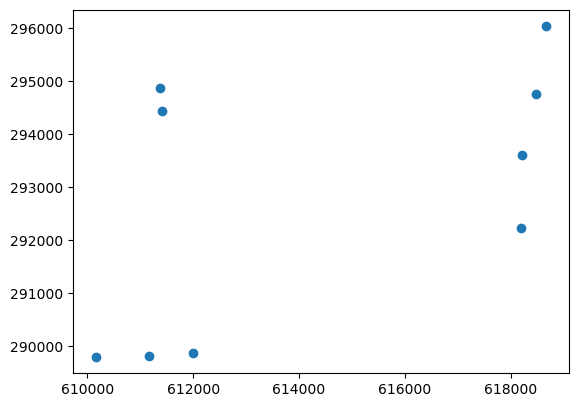

In [37]:
road_nodes_clipped.plot()

# 2. Build the complex network

In [59]:
edges_gdf_raw = edges_gdf.to_crs(target_crs)

## geospatial visualization

/var/folders/g3/6qgb9yms7_nfyz1zwmncn97m0000gn/T/ipykernel_53584/807392975.py:67: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=14)


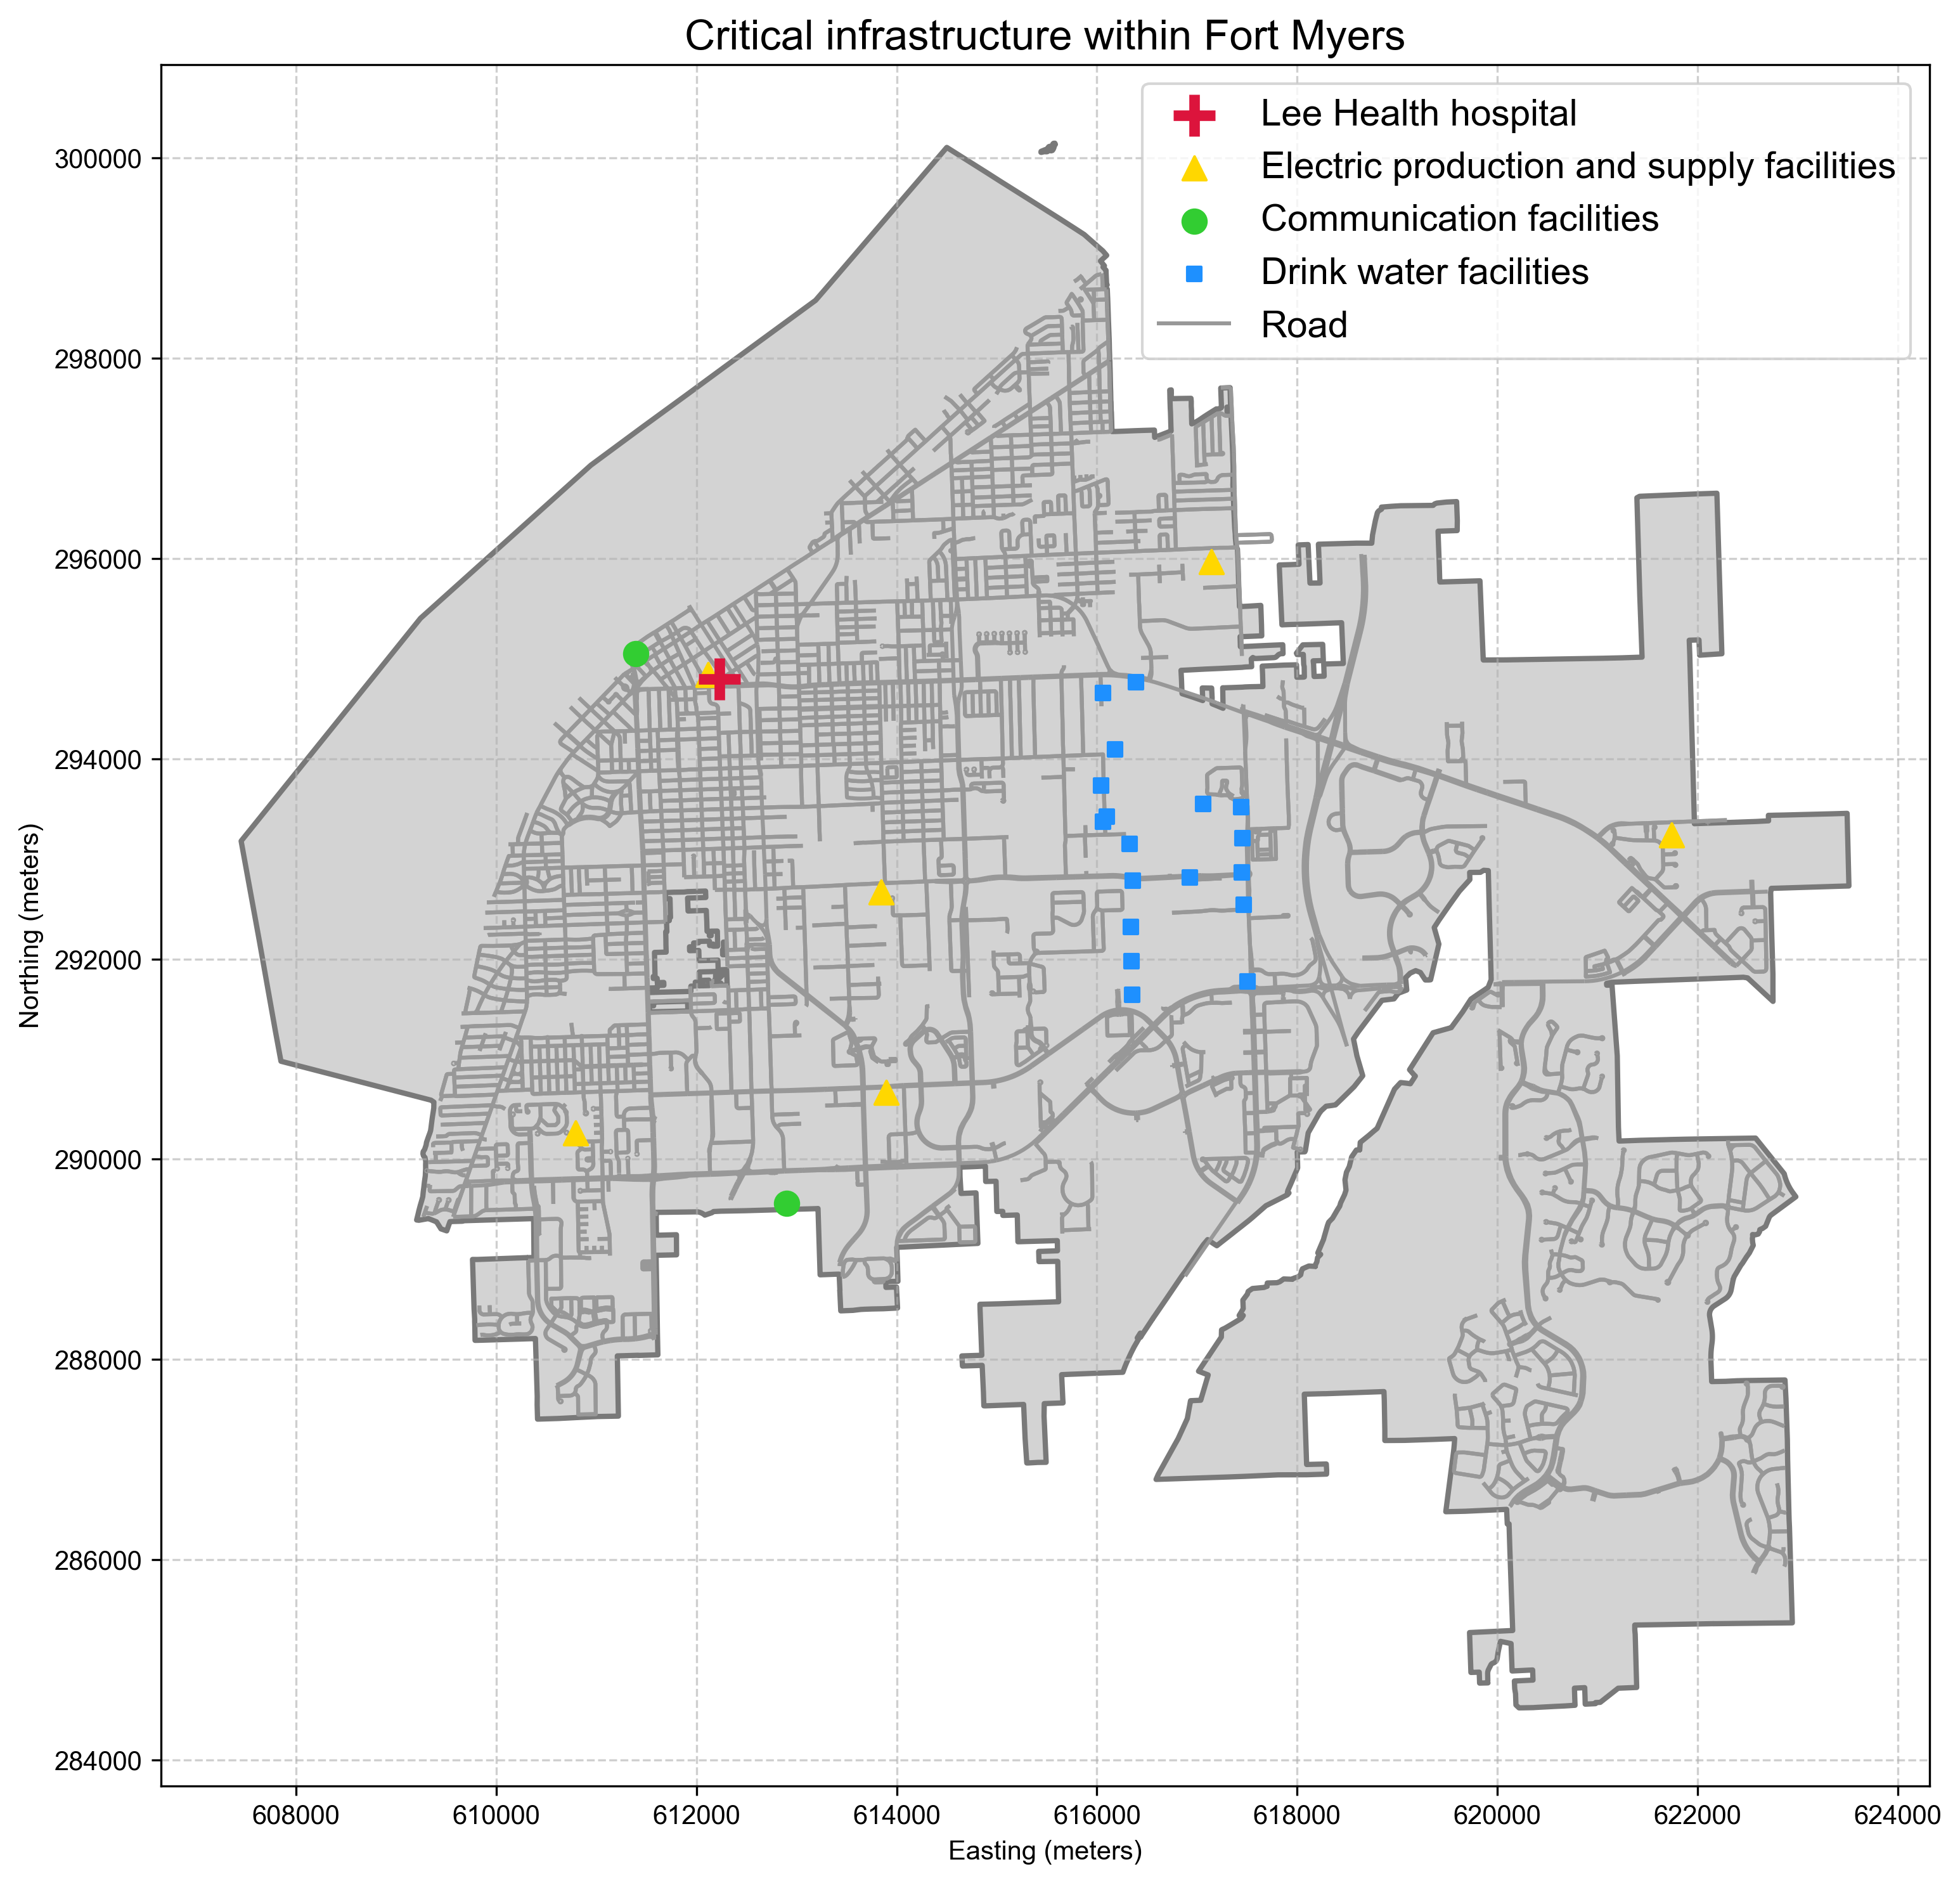

In [85]:
# Create a figure and axes for the plot
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"] 
fig, ax = plt.subplots(figsize=(12, 12), dpi=300)

fort_myers_boundary.plot(
    ax=ax,
    color='lightgray',
    edgecolor="#797979",
    linewidth=2,
    label='Fort Myers City Boundary',
    zorder=1
)

hospital.plot(
    ax=ax,
    color='crimson',
    markersize=250,
    label='Lee Health hospital',
    marker='+',
    linewidth=4,
    zorder=4
)

ele_clipped.plot(
    ax=ax,
    color='gold',
    markersize=80,
    label='Electric production and supply facilities',
    marker='^',
    zorder=3
)

com_clipped.plot(
    ax=ax,
    color='limegreen',
    markersize=80,
    label='Communication facilities',
    marker='o',
    zorder=3
)

water_clipped.plot(
    ax=ax,
    color='dodgerblue',
    markersize=30,
    label='Drink water facilities',
    marker='s',
    zorder=3
)


edges_gdf_raw.plot(
    ax=ax,
    color="#989898",
    markersize=2,
    label='Road',
    marker='-',
    zorder=2
)


# Customize the plot for clarity
ax.set_title('Critical infrastructure within Fort Myers', fontsize=16)
ax.set_xlabel('Easting (meters)')
ax.set_ylabel('Northing (meters)')
ax.legend(fontsize=14)
ax.grid(True, linestyle='--', alpha=0.6)

# Show the final map
plt.show()

--- Step 1: Unifying nodes into a single DataFrame ---
Created a unified DataFrame with 8 total nodes.

--- Step 2: Building the network based on proximity ---
Network built. Nodes: 8, Edges: 13.

--- Step 3: Analyzing network centrality ---
Top 5 Most Critical Nodes (by Betweenness Centrality):
  - Node ele_3: Centrality = 0.2857
  - Node ele_1: Centrality = 0.1429
  - Node com_0: Centrality = 0.0000
  - Node com_1: Centrality = 0.0000
  - Node ele_0: Centrality = 0.0000


--- Step 4: Visualizing the network on a geographic map ---


/opt/anaconda3/envs/demo/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/anaconda3/envs/demo/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/opt/anaconda3/envs/demo/lib/python3.13/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

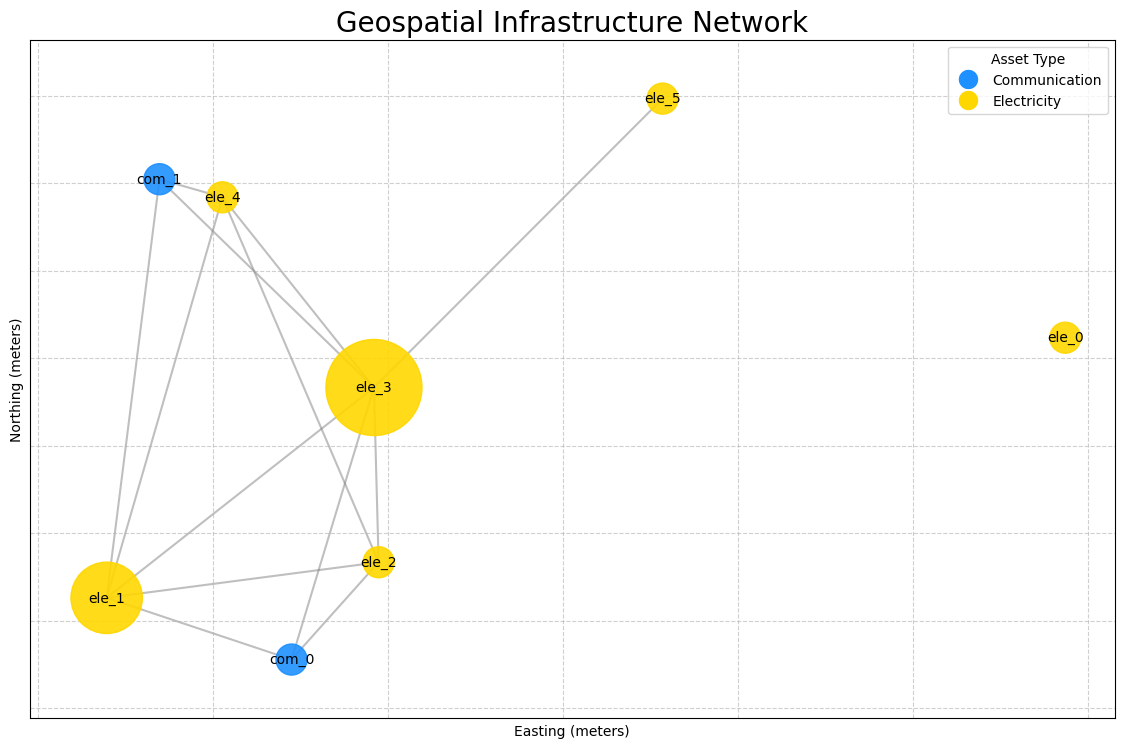

In [134]:
# =============================================================================
# STEP 1: CREATE A UNIFIED NODE DATAFRAME
# =============================================================================
# We combine both layers into a single GeoDataFrame to manage all nodes together.

print("--- Step 1: Unifying nodes into a single DataFrame ---")
com_clipped['layer_type'] = 'communication'
ele_clipped['layer_type'] = 'electricity'

# Create a unique ID for each node, which is crucial for the network
com_clipped['node_id'] = ['com_' + str(i) for i in range(len(com_clipped))]
ele_clipped['node_id'] = ['ele_' + str(i) for i in range(len(ele_clipped))]

all_nodes_gdf = pd.concat([com_clipped, ele_clipped], ignore_index=True)
print(f"Created a unified DataFrame with {len(all_nodes_gdf)} total nodes.\n")


# =============================================================================
# STEP 2: BUILD THE PROXIMITY-BASED NETWORK
# =============================================================================
# An edge is created if two nodes are within a specified distance of each other.

print("--- Step 2: Building the network based on proximity ---")
G = nx.Graph()

# Add each feature from the GeoDataFrame as a node in the graph
for index, node_data in all_nodes_gdf.iterrows():
    # The **node_data.to_dict() unpacks all columns as node attributes
    G.add_node(node_data['node_id'], **node_data.to_dict())

# Define the distance threshold in the units of your CRS (e.g., meters)
DISTANCE_THRESHOLD = 5000  # 5 kilometers

nodes_with_data = list(G.nodes(data=True))
for i in range(len(nodes_with_data)):
    for j in range(i + 1, len(nodes_with_data)):
        node1_id, node1_attrs = nodes_with_data[i]
        node2_id, node2_attrs = nodes_with_data[j]

        # Calculate the distance between the two nodes
        distance = node1_attrs['geometry'].distance(node2_attrs['geometry'])

        # If the distance is within the threshold, create an edge
        if distance <= DISTANCE_THRESHOLD:
            # The weight is often the inverse of the distance (closer = stronger link)
            weight = 1 / distance if distance > 0 else 1.0
            G.add_edge(node1_id, node2_id, weight=weight, distance=f"{distance:.2f}m")

print(f"Network built. Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}.\n")


# =============================================================================
# STEP 3: ANALYZE THE NETWORK
# =============================================================================
# We calculate a centrality metric to identify critical nodes.

print("--- Step 3: Analyzing network centrality ---")
if G.number_of_edges() > 0:
    # Betweenness centrality identifies nodes that act as bridges in the network
    betweenness_centrality = nx.betweenness_centrality(G, weight='weight', normalized=True)
    nx.set_node_attributes(G, betweenness_centrality, 'betweenness')
    
    print("Top 5 Most Critical Nodes (by Betweenness Centrality):")
    sorted_centrality = sorted(betweenness_centrality.items(), key=lambda item: item[1], reverse=True)
    for node, centrality in sorted_centrality[:5]:
        print(f"  - Node {node}: Centrality = {centrality:.4f}")
else:
    print("No edges were created. Skipping centrality analysis.")
    # If no edges, create a dummy 'betweenness' attribute for visualization
    nx.set_node_attributes(G, 0, 'betweenness')

print("\n")


# =============================================================================
# STEP 4: VISUALIZE THE NETWORK GEOGRAPHICALLY
# =============================================================================
# The nodes are plotted at their actual coordinates from the shapefile.

print("--- Step 4: Visualizing the network on a geographic map ---")
fig, ax = plt.subplots(figsize=(14, 14))

# Create a dictionary of node positions from their geometry attribute
# This is the key to plotting them in their real-world locations
pos = {node_id: (data['geometry'].x, data['geometry'].y) 
       for node_id, data in G.nodes(data=True)}

# Get node attributes for styling the plot
node_colors = ['dodgerblue' if G.nodes[node]['layer_type'] == 'communication' else 'gold' for node in G.nodes]
centrality_values = nx.get_node_attributes(G, 'betweenness')
node_sizes = [c * 15000 + 500 for c in centrality_values.values()]

# Draw the network elements on the matplotlib axes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.5, edge_color='gray', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)

# Customize the final plot
ax.set_title('Geospatial Infrastructure Network', fontsize=20)
ax.set_xlabel("Easting (meters)")
ax.set_ylabel("Northing (meters)")
ax.tick_params(axis='x', rotation=45)
ax.set_aspect('equal', adjustable='box') # Ensures the map scale is correct
ax.grid(True, linestyle='--', alpha=0.6)

# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', label='Communication', markerfacecolor='dodgerblue', markersize=15),
           plt.Line2D([0], [0], marker='o', color='w', label='Electricity', markerfacecolor='gold', markersize=15)]
ax.legend(title='Asset Type', handles=handles)

plt.show()

In [135]:
def print_fram_aspects(graph, node_id):
    """
    Prints a formatted list of the six FRAM aspects for a specific node.
    """
    if node_id not in graph:
        print(f"Error: Node '{node_id}' not found in the graph.")
        return

    print(f"--- FRAM Profile for Node: {node_id} ---")
    attrs = graph.nodes[node_id]
    
    # Define the six aspects we're looking for
    fram_keys = ['Input', 'Output', 'Precondition', 'Resource', 'Time', 'Control']
    
    for key in fram_keys:
        # Use .get() to avoid an error if an aspect is missing
        value = attrs.get(key, 'Not Defined')
        print(f"{key:<15}: {value}")

# --- Example Usage ---
# Use the function to inspect an electricity node
print_fram_aspects(G, 'ele_3')

print("-" * 35)

# Inspect a communication node
print_fram_aspects(G, 'com_1')

--- FRAM Profile for Node: ele_3 ---
Input          : Not Defined
Output         : Not Defined
Precondition   : Not Defined
Resource       : Not Defined
Time           : Not Defined
Control        : Not Defined
-----------------------------------
--- FRAM Profile for Node: com_1 ---
Input          : Not Defined
Output         : Not Defined
Precondition   : Not Defined
Resource       : Not Defined
Time           : Not Defined
Control        : Not Defined


# 3. Test model - assign FRAM attributes to nodes

In [209]:
# A dictionary where keys are your node IDs and values are their FRAM profiles.
fram_test_data = {
    # --- Communication Nodes ---
    'com_0': {
        'asset_type': 'Public Cell Tower',
        'Input': 'Data Backhaul (Fiber)',
        'Output': 'Public 4G/5G Signal',
        'Precondition': 'Customer Demand in Area',
        'Resource': 'Grid Power (Standard)', # <<< LINKS to ele_1
        'Time': '24/7 Continuous',
        'Control': 'Telecom Network Operations Center'
    },
    'com_1': {
        'asset_type': 'Utility SCADA Microwave Tower',
        'Input': 'Sensor & Control Data',
        'Output': 'Utility SCADA Signal', # <<< LINKS to ele_5, ele_0, ele_1
        'Precondition': 'Clear Line-of-Sight',
        'Resource': 'Grid Power (Priority)', # <<< LINKS to ele_1
        'Time': 'Real-time, Millisecond Latency',
        'Control': 'Utility Control System' # <<< LINKS to ele_5
    },

    # --- Electricity Nodes ---
    'ele_0': {
        'asset_type': 'Regional Substation',
        'Input': 'High-Voltage Transmission Feed',
        'Output': 'Medium-Voltage Distribution Power',
        'Precondition': 'Upstream Grid is Stable',
        'Resource': 'Cooling Systems',
        'Time': 'Continuous Load Balancing',
        'Control': 'Remote Control via SCADA' # <<< LINKS to com_1
    },
    'ele_1': {
        'asset_type': 'Distribution Substation',
        'Input': 'Medium-Voltage Distribution Power',
        'Output': 'Grid Power (Standard)', # <<< LINKS to com_0, com_1
        'Precondition': 'Regional Substation is Online',
        'Resource': 'Transformers, Switchgear',
        'Time': 'Follows Daily Demand Curve',
        'Control': 'Remote Control via SCADA' # <<< LINKS to com_1
    },
    'ele_2': {
        'asset_type': 'Solar Farm',
        'Input': 'Sunlight',
        'Output': 'Variable DC Power',
        'Precondition': 'Daylight Hours',
        'Resource': 'Inverters, Land Area',
        'Time': 'Diurnal Cycle (Daytime Only)',
        'Control': 'Automated Generation Management'
    },
    'ele_3': {
        'asset_type': 'Natural Gas Peaker Plant',
        'Input': 'Natural Gas Supply',
        'Output': 'On-Demand AC Power',
        'Precondition': 'Grid Demand Exceeds Baseload',
        'Resource': 'Fuel, Water for Cooling',
        'Time': 'On-Demand (Starts in Minutes)',
        'Control': 'Dispatch Order from Control Center' # <<< LINKS to ele_5
    },
    'ele_4': {
        'asset_type': 'Smart Distribution Line',
        'Input': 'Power from Substation',
        'Output': 'Power to End-Users',
        'Precondition': 'Circuit is Closed',
        'Resource': 'Physical Poles and Wires',
        'Time': 'Continuous',
        'Control': 'Automated Reclosers & Sensors'
    },
    'ele_5': {
        'asset_type': 'Utility Control Center',
        'Input': 'Utility SCADA Signal', # <<< LINKS to com_1
        'Output': 'Dispatch Order from Control Center', # <<< LINKS to ele_3
        'Precondition': 'Staffed with Operators',
        'Resource': 'Backup Generators, IT Infrastructure',
        'Time': '24/7 Monitoring',
        'Control': 'Human System Operators'
    }
}

In [212]:
# A dictionary of predefined FRAM attributes for testing
fram_test_data = { ... } # Copy the dictionary from above here

def assign_fram_attributes_from_test_data(row):
    """
    Looks up the node's ID in the predefined test data dictionary
    and returns its FRAM profile.
    """
    node_id = row['node_id']
    
    # Get the FRAM profile for the given node, or return an empty Series if not found
    aspects = fram_test_data.get(node_id, {})
    
    return pd.Series(aspects)

# --- Then, in your main script, apply this new function ---
# (Make sure 'node_id' column has been created first)

# fram_aspects = all_nodes_gdf.apply(assign_fram_attributes, axis=1) # Your old line
fram_aspects = all_nodes_gdf.apply(assign_fram_attributes_from_test_data, axis=1) # The new line
all_nodes_gdf = pd.concat([all_nodes_gdf, fram_aspects], axis=1)

AttributeError: 'set' object has no attribute 'get'

In [213]:
fram_test_data

{Ellipsis}

## A flood event

In [208]:
# --- STEP 1: DEFINE THE FLOOD EVENT ---
# --- Identify the target and get its location ---
target_node_id = 'ele_1'
target_location = all_nodes_gdf.loc[all_nodes_gdf['node_id'] == target_node_id, 'geometry'].iloc[0]
x, y = target_location.x, target_location.y

print(f"Designing flood polygon to cover the critical node '{target_node_id}' at ({x}, {y}).")

# --- Design a polygon that covers the target's coordinates ---
# We'll create a 2x2 unit square centered around the node.
flood_vertices = [
    (x - 1000, y - 1000),  # Bottom-left
    (x + 1000, y - 1000),  # Bottom-right
    (x + 1000, y + 1000),  # Top-right
    (x - 1000, y + 1000)   # Top-left
]
flood_polygon = Polygon(flood_vertices)

# Create the final GeoDataFrame for the flood event
flood_gdf = gpd.GeoDataFrame([1], geometry=[flood_polygon], crs="EPSG:3087")

Designing flood polygon to cover the critical node 'ele_1' at (3.0, 7.0).


/var/folders/g3/6qgb9yms7_nfyz1zwmncn97m0000gn/T/ipykernel_87440/3308579012.py:42: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


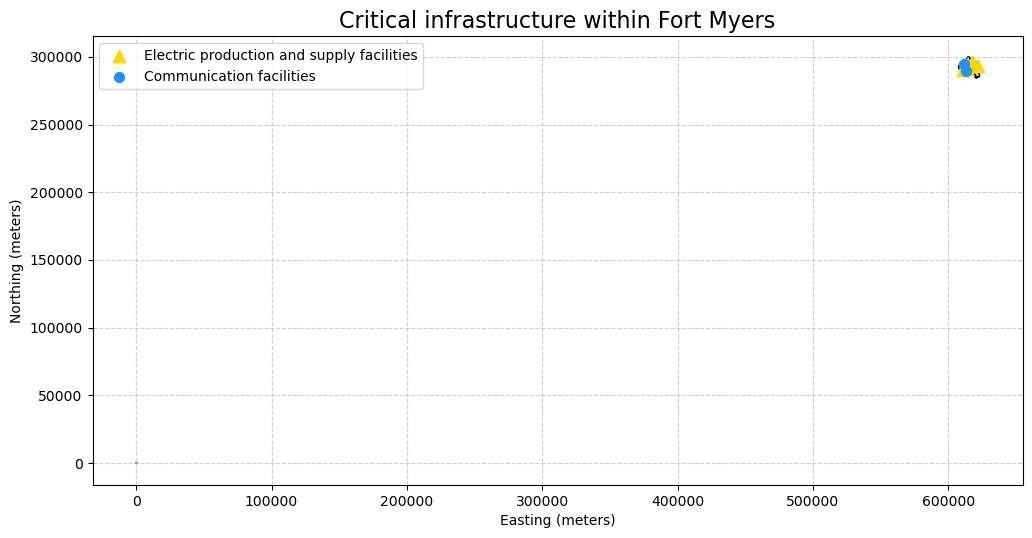

In [205]:
# Create a figure and axes for the plot
fig, ax = plt.subplots(figsize=(12, 12))

# Plot the boundary layer first
fort_myers_boundary.plot(
    ax=ax,
    color='lightgray',
    edgecolor='black',
    label='Fort Myers City Boundary'
)

# Plot the clipped electricity layer on the same axes
ele_clipped.plot(
    ax=ax,
    color='gold',
    markersize=80,
    label='Electric production and supply facilities',
    marker='^' # Triangle marker
)

# Plot the clipped communication layer on the same axes
com_clipped.plot(
    ax=ax,
    color='dodgerblue',
    markersize=50,
    label='Communication facilities',
    marker='o' # Circle marker
)

flood_gdf.plot(
    ax=ax,
    color='blue',
    edgecolor=None,
    alpha=0.5,
    label='Flood zone'
)

# Customize the plot for clarity
ax.set_title('Critical infrastructure within Fort Myers', fontsize=16)
ax.set_xlabel('Easting (meters)')
ax.set_ylabel('Northing (meters)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# Show the final map
plt.show()

INITIAL FAILURES (in flood zone): set()

--- Starting Cascade Simulation ---

--- Cascade stabilized. No new failures. ---

Total nodes failed: 0
Final failed set: set()



/var/folders/g3/6qgb9yms7_nfyz1zwmncn97m0000gn/T/ipykernel_87440/681177294.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  initial_failures_gdf = all_nodes_gdf[all_nodes_gdf.within(flood_gdf.unary_union)]


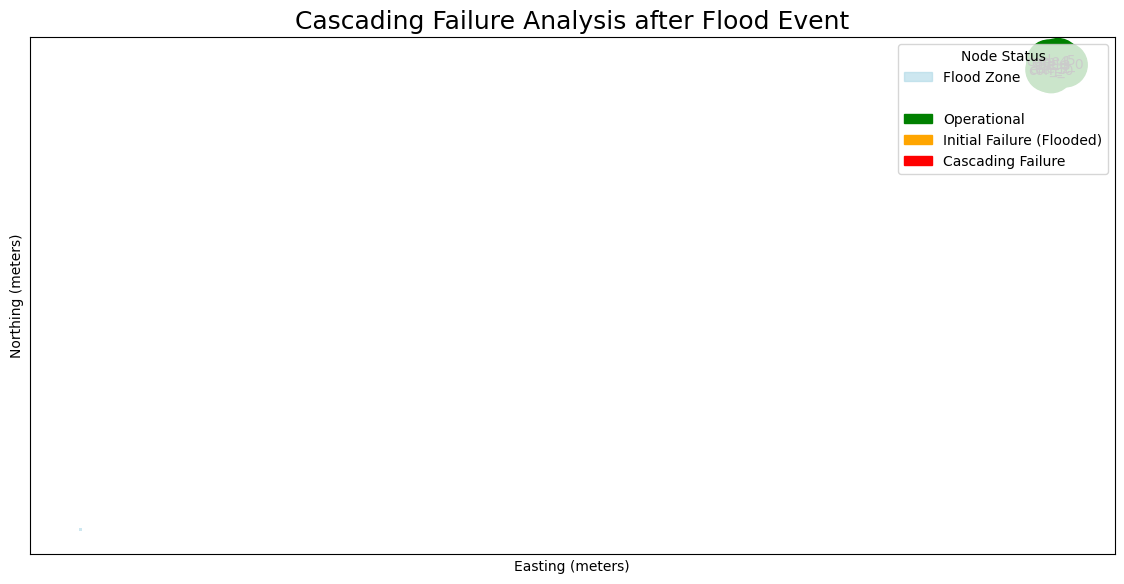

In [147]:
# --- STEP 2: IDENTIFY INITIAL FAILURES ---
initial_failures_gdf = all_nodes_gdf[all_nodes_gdf.within(flood_gdf.unary_union)]
failed_nodes = set(initial_failures_gdf['node_id'])
initial_failed_nodes = failed_nodes.copy()
print(f"INITIAL FAILURES (in flood zone): {initial_failed_nodes}\n")

# --- STEP 3: RUN THE CASCADING FAILURE SIMULATION ---
print("--- Starting Cascade Simulation ---")
iteration = 1
while True:
    newly_failed_nodes = set()
    operational_nodes = [n for n in G.nodes() if n not in failed_nodes]
    
    for node_id in operational_nodes:
        node_attrs = G.nodes[node_id]
        # Check for dependency failures (this can be customized)
        dependency_failed = False
        
        # Rule 1: Node fails if its required Resource is unavailable
        required_resource = node_attrs.get('Resource')
        if required_resource in suppliers:
            if all(supplier in failed_nodes for supplier in suppliers[required_resource]):
                dependency_failed = True
                print(f"Iter {iteration}: {node_id} failed (Resource '{required_resource}' lost)")
        
        # Rule 2: Node fails if its required Input is unavailable
        required_input = node_attrs.get('Input')
        if not dependency_failed and required_input in suppliers:
            if all(supplier in failed_nodes for supplier in suppliers[required_input]):
                dependency_failed = True
                print(f"Iter {iteration}: {node_id} failed (Input '{required_input}' lost)")

        if dependency_failed:
            newly_failed_nodes.add(node_id)

    if not newly_failed_nodes:
        print("\n--- Cascade stabilized. No new failures. ---")
        break
    
    failed_nodes.update(newly_failed_nodes)
    iteration += 1

# --- STEP 4: ANALYZE AND VISUALIZE THE RESULTS ---
print(f"\nTotal nodes failed: {len(failed_nodes)}")
print(f"Final failed set: {failed_nodes}\n")

# Assign a final status to each node for visualization
for node_id in G.nodes():
    if node_id in initial_failed_nodes:
        G.nodes[node_id]['status'] = 'Initial Failure'
    elif node_id in failed_nodes:
        G.nodes[node_id]['status'] = 'Cascading Failure'
    else:
        G.nodes[node_id]['status'] = 'Operational'

color_map = {'Operational': 'green', 'Initial Failure': 'orange', 'Cascading Failure': 'red'}
node_colors = [color_map[G.nodes[n]['status']] for n in G.nodes()]

# Visualize the final state
fig, ax = plt.subplots(figsize=(14, 14))
pos = {n: (d['geometry'].x, d['geometry'].y) for n, d in G.nodes(data=True)}
flood_gdf.plot(ax=ax, color='lightblue', alpha=0.6)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1000, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)
ax.set_title('Cascading Failure Analysis after Flood Event', fontsize=18)
plt.xlabel("Easting (meters)")
plt.ylabel("Northing (meters)")

# Create a custom legend
legend_handles = [
    Patch(color='lightblue', alpha=0.6, label='Flood Zone'),
    Patch(color='white', label=''), # Spacer
    Patch(color='green', label='Operational'),
    Patch(color='orange', label='Initial Failure (Flooded)'),
    Patch(color='red', label='Cascading Failure')
]
plt.legend(handles=legend_handles, title='Node Status', loc='upper right')
plt.show()

# 4. FRAM

In [1]:
import framalytics

In [2]:
fram = framalytics.FRAM("/Users/yuhan/Library/CloudStorage/OneDrive-GeorgiaInstituteofTechnology/06_Research_PRJ_2025_HCI/FRAM_Model/MyModel/FMV_HCI.xfmv")

In [3]:
fram.number_of_functions()

11

In [5]:
fram.get_connections()

,fromFn,toFn,toAspect,Name
0,6,7,I,Bulk electrical power
1,7,8,I,High-voltage power
2,8,1,R,End-user electricity
3,9,1,R,On-site personnel
4,9,6,R,On-site personnel
5,9,7,R,On-site personnel
6,9,8,R,On-site personnel
7,8,9,R,End-user electricity
8,10,1,R,Delivered goods & supplies
9,10,6,R,Delivered goods & supplies


IndexError: list assignment index out of range

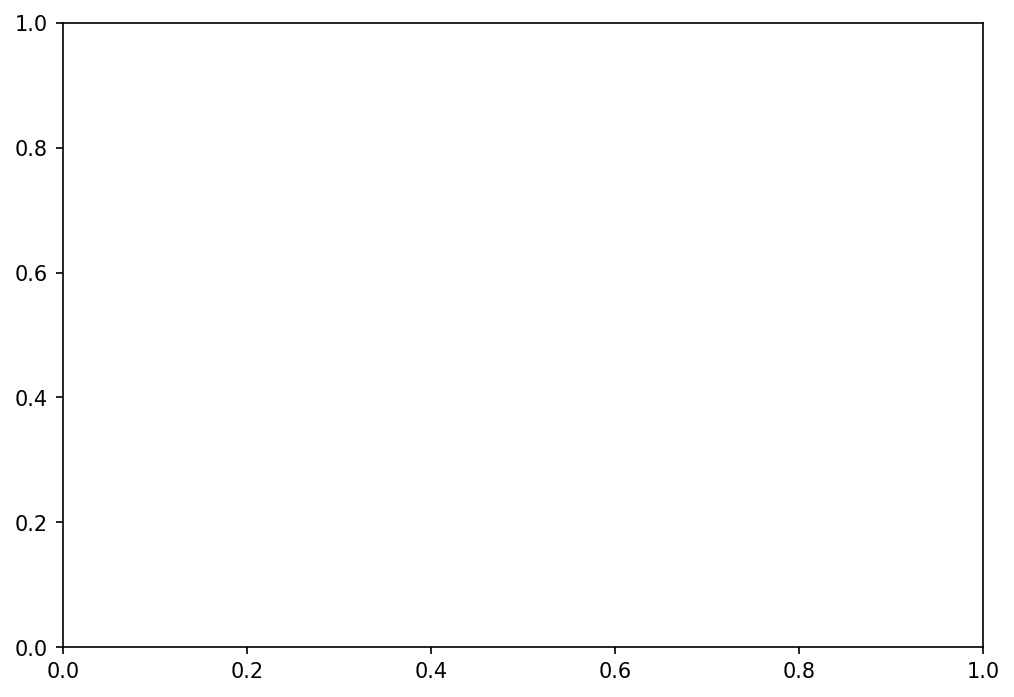

In [6]:
fram.visualize()